In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx
from shapely.geometry import LineString
from pathlib import Path

from treecrown_nz import load_suburbs, load_canopy, canopy_coverage, route_shade

In [2]:
suburbs = load_suburbs()

print(suburbs.shape)
print(suburbs.crs)
print(suburbs.columns.tolist())
suburbs.head()

(57, 7)
EPSG:2193
['OBJECTID', 'postcode', 'supply_dat', 'suburb', 'Shape.STArea()', 'Shape.STLength()', 'geometry']


,OBJECTID,postcode,supply_dat,suburb,Shape.STArea(),Shape.STLength(),geometry
0,1,6023,20030821,Berhampore,1.669267e+06,6612.318897,"POLYGON ((1748297.299 5424675.308, 1748293.509..."
1,2,6022,20030821,Breaker Bay,5.539493e+05,8308.105340,"POLYGON ((1753785.082 5422803.445, 1753798.285..."
2,3,6037,20060707,Churton Park,3.961987e+06,12625.743911,"POLYGON ((1751817.998 5437481.825, 1751822.443..."
3,4,6035,20030821,Crofton Downs,1.415715e+06,7294.937137,"POLYGON ((1747548.638 5431679.93, 1747521.616 ..."
4,5,6037,20030821,Glenside,2.065260e+06,7925.608990,"POLYGON ((1751897.947 5437511.281, 1751875.909..."


In [3]:
possible_name_cols = ["suburb"]

name_col = None
for col in possible_name_cols:
    if col in suburbs.columns:
        name_col = col
        break

if name_col is None:
    raise ValueError(f"Could not find suburb name column. Columns are: {suburbs.columns.tolist()}")

print("Using suburb name column:", name_col)
print(suburbs[name_col].sort_values().head(30).to_list())

Using suburb name column: suburb
['Aro Valley', 'Berhampore', 'Breaker Bay', 'Broadmeadows', 'Brooklyn', 'Churton Park', 'Crofton Downs', 'Glenside', 'Grenada North', 'Grenada Village', 'Hataitai', 'Highbury', 'Horokiwi', 'Houghton Bay', 'Island Bay', 'Johnsonville', 'Kaiwharawhara', 'Karaka Bays', 'Karori', 'Kelburn', 'Khandallah', 'Kilbirnie', 'Kingston', 'Lyall Bay', 'Makara', 'Makara Beach', 'Maupuia', 'Melrose', 'Miramar', 'Moa Point']


In [4]:
selected_names = ["Aro Valley", "Breaker Bay", "Broadmeadows"]

selected_suburbs = suburbs[
    suburbs[name_col].str.lower().isin([name.lower() for name in selected_names])
].copy()

print(selected_suburbs[[name_col]].to_string(index=False))
print(selected_suburbs.shape)

      suburb
 Breaker Bay
Broadmeadows
  Aro Valley
(3, 7)


In [5]:
results = []

for i, row in suburbs.iterrows():
    one_suburb = gpd.GeoDataFrame(
        [row],
        geometry="geometry",
        crs=suburbs.crs,
    )

    suburb_name = row[name_col]

    try:
        canopy = load_canopy(tuple(one_suburb.total_bounds))
        coverage = canopy_coverage(one_suburb, canopy)

        results.append(
            {
                "suburb": suburb_name,
                "area_m2": coverage.iloc[0]["area_m2"],
                "canopy_area_m2": coverage.iloc[0]["canopy_area_m2"],
                "canopy_pct": coverage.iloc[0]["canopy_pct"],
            }
        )

        print(f"Done: {suburb_name}")

    except Exception as e:
        print(f"Skipped {suburb_name}: {e}")

all_coverage = pd.DataFrame(results)

all_coverage = all_coverage.sort_values("canopy_pct", ascending=False)

all_coverage.head(20)

Done: Berhampore
Done: Breaker Bay
Done: Churton Park
Done: Crofton Downs
Done: Glenside
Done: Horokiwi
Done: Johnsonville
Done: Kingston
Done: Lyall Bay
Done: Moa Point
Done: Mornington
Done: Newlands
Done: Ngaio
Done: Ngauranga
Done: Northland
Done: Ohariu
Done: Paparangi
Done: Pipitea
Done: Rongotai
Done: Southgate
Done: Strathmore Park
Done: Te Aro
Done: Thorndon
Done: Woodridge
Done: Karaka Bays
Done: Maupuia
Done: Hataitai
Done: Roseneath
Done: Oriental Bay
Done: Wellington Central
Done: Makara Beach
Done: Takapu Valley
Done: Tawa
Done: Grenada North
Done: Grenada Village
Done: Highbury
Done: Kelburn
Done: Houghton Bay
Done: Melrose
Done: Miramar
Done: Seatoun
Done: Broadmeadows
Done: Khandallah
Done: Aro Valley
Done: Island Bay
Done: Kaiwharawhara
Done: Kilbirnie
Done: Newtown
Done: Wadestown
Done: Wilton
Done: Mount Victoria
Done: Mount Cook
Done: Karori
Done: Owhiro Bay
Done: Makara
Done: Vogeltown
Done: Brooklyn


,suburb,area_m2,canopy_area_m2,canopy_pct
35,Highbury,2.985682e+05,213896.391095,71.640717
43,Aro Valley,8.249746e+05,367807.620229,44.584114
24,Karaka Bays,4.588217e+05,181449.843318,39.546921
10,Mornington,3.233065e+05,123666.674004,38.250597
55,Vogeltown,2.704066e+05,91795.914109,33.947359
28,Oriental Bay,3.339234e+05,112507.983011,33.692754
27,Roseneath,5.333233e+05,136284.465736,25.553820
38,Melrose,5.185129e+05,132320.185476,25.519168
48,Wadestown,1.412844e+06,316398.500529,22.394441
7,Kingston,4.867852e+05,92855.729226,19.075300


In [6]:
top3 = all_coverage.head(3).copy()
top3

,suburb,area_m2,canopy_area_m2,canopy_pct
35,Highbury,298568.189553,213896.391095,71.640717
43,Aro Valley,824974.613324,367807.620229,44.584114
24,Karaka Bays,458821.667539,181449.843318,39.546921


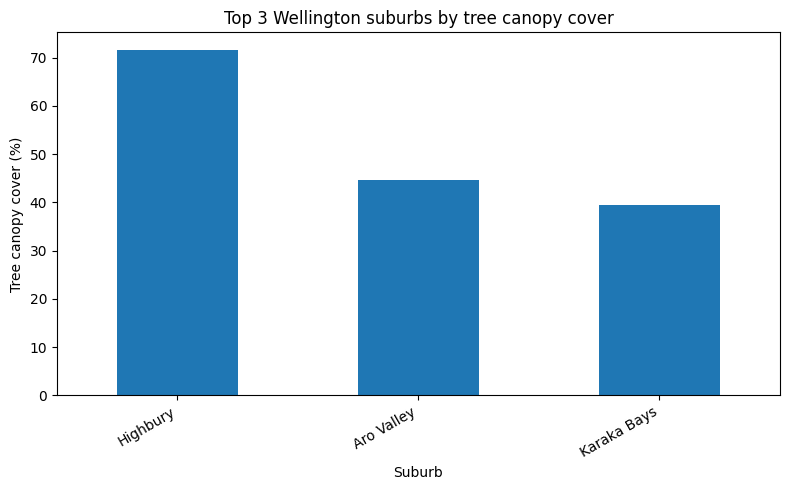

In [7]:
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

ax = top3.plot(
    kind="bar",
    x="suburb",
    y="canopy_pct",
    legend=False,
    figsize=(8, 5),
)

ax.set_title("Top 3 Wellington suburbs by tree canopy cover")
ax.set_xlabel("Suburb")
ax.set_ylabel("Tree canopy cover (%)")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig("outputs/top3_suburb_canopy_bar_graph.png", dpi=200)
plt.show()

In [8]:
top3_names = top3["suburb"].to_list()

top3_suburbs = suburbs[
    suburbs[name_col].isin(top3_names)
].copy()

print(top3_names)
print(top3_suburbs[[name_col]])
print(top3_suburbs.crs)
print(top3_suburbs.total_bounds)

['Highbury', 'Aro Valley', 'Karaka Bays']
         suburb
24  Karaka Bays
35     Highbury
43   Aro Valley
EPSG:2193
[1746499.8067 5424974.7516 1753687.8826 5427649.7098]


In [9]:
canopy_parts = []

for _, row in top3_suburbs.iterrows():
    suburb_name = row[name_col]
    
    one_suburb = gpd.GeoDataFrame(
        [row],
        geometry="geometry",
        crs=top3_suburbs.crs,
    )
    
    one_canopy = load_canopy(tuple(one_suburb.total_bounds))
    
    print(suburb_name, one_canopy.shape)
    
    canopy_parts.append(one_canopy)

top3_canopy = gpd.GeoDataFrame(
    pd.concat(canopy_parts, ignore_index=True),
    crs="EPSG:2193",
)

print(top3_canopy.shape)
print(top3_canopy.crs)

Karaka Bays (1382, 4)
Highbury (969, 4)
Aro Valley (2000, 4)
(4351, 4)
EPSG:2193


In [10]:
for _, row in top3_suburbs.iterrows():
    suburb_name = row[name_col]
    geom = row.geometry
    
    intersects_count = top3_canopy.intersects(geom).sum()
    
    print(suburb_name, "intersecting canopy polygons:", intersects_count)

Karaka Bays intersecting canopy polygons: 759
Highbury intersecting canopy polygons: 522
Aro Valley intersecting canopy polygons: 1574


In [11]:
top3_canopy = top3_canopy.drop_duplicates(subset="geometry").copy()
print(top3_canopy.shape)

(3683, 4)


In [12]:
top3_coverage = canopy_coverage(top3_suburbs, top3_canopy)

top3_coverage[[name_col, "area_m2", "canopy_area_m2", "canopy_pct"]]

,suburb,area_m2,canopy_area_m2,canopy_pct
24,Karaka Bays,458821.667539,181449.843318,39.546921
35,Highbury,298568.189553,213896.391095,71.640717
43,Aro Valley,824974.613324,378993.469116,45.940016


In [13]:
chosen_suburb = "Karaka Bays"

chosen_area = suburbs[
    suburbs[name_col].str.lower() == chosen_suburb.lower()
].copy()

print(chosen_area[[name_col]])
print(chosen_area.shape)
print(chosen_area.crs)

         suburb
24  Karaka Bays
(1, 7)
EPSG:2193


In [14]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

karaka_polygon_4326 = chosen_area.to_crs("EPSG:4326").geometry.iloc[0]
karaka_polygon_4326_buffered = karaka_polygon_4326.buffer(0.003)

G = ox.graph_from_polygon(
    karaka_polygon_4326_buffered,
    network_type="walk",
    simplify=True,
)

G = ox.project_graph(G, to_crs="EPSG:2193")

nodes, edges = ox.graph_to_gdfs(G)

edges = edges.to_crs("EPSG:2193")

print("Nodes:", len(nodes))
print("Edges:", len(edges))
edges[["name", "length", "geometry"]].head()

Nodes: 272
Edges: 674


name     length  \
u          v           key                               
34543647   1193729414  0    Darlington Road  12.178246   
           2780709898  0    Darlington Road  81.165558   
           2812418293  0    Camperdown Road  30.844188   
1193729414 34543647    0    Darlington Road  12.178246   
           13394204390 0                NaN   6.614078   

                                                                     geometry  
u          v           key                                                     
34543647   1193729414  0    LINESTRING (1752852.533 5425570.552, 1752849.5...  
           2780709898  0    LINESTRING (1752852.533 5425570.552, 1752853.5...  
           2812418293  0    LINESTRING (1752852.533 5425570.552, 1752868.6...  
1193729414 34543647    0    LINESTRING (1752849.58 5425558.752, 1752852.53...  
           13394204390 0    LINESTRING (1752849.58 5425558.752, 1752852.91...

In [15]:
edges_in_suburb = gpd.clip(edges, chosen_area)

print(edges_in_suburb.shape)
edges_in_suburb[["name", "length", "geometry"]].head(20)

(246, 13)


,,,name,length,geometry
u,v,key,,,
4381863945,147862602,0,Nevay Road,147.645130,"LINESTRING (1753004.604 5425111.399, 1752982.5..."
147862602,4381863945,0,Nevay Road,147.645130,"LINESTRING (1752968.357 5424980.903, 1752969.9..."
13394188811,13394188683,0,NaN,149.030235,"MULTILINESTRING ((1752969.123 5425069.754, 175..."
13394188683,13394188811,0,NaN,149.030235,"MULTILINESTRING ((1752963.019 5424985.714, 175..."
4381863945,13394188811,0,NaN,4.000819,"LINESTRING (1753004.604 5425111.399, 1753003.1..."
172773159,4381863945,0,Nevay Road,591.302399,"MULTILINESTRING ((1753153.626 5425640.916, 175..."
4381863945,172773159,0,Nevay Road,591.302399,"MULTILINESTRING ((1753004.604 5425111.399, 175..."
13394188811,4381863945,0,NaN,4.000819,"LINESTRING (1753003.1 5425112.618, 1753004.604..."
2908338002,13394188757,0,Camperdown Road,5.203279,"LINESTRING (1753146.834 5425646.857, 1753143.4..."


In [16]:
named_edges = edges_in_suburb.copy()

named_edges = named_edges[named_edges["name"].notna()].copy()

named_edges["road_name"] = named_edges["name"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) else str(x)
)

named_edges = named_edges.reset_index()

named_edges["edge_pair"] = named_edges.apply(
    lambda row: tuple(sorted([row["u"], row["v"]])),
    axis=1,
)

named_edges_clean = named_edges.drop_duplicates(
    subset=["edge_pair", "road_name", "length"]
).copy()

named_edges_clean[["road_name", "length", "geometry"]].sort_values("road_name").head(50)

,road_name,length,geometry
4,Camperdown Road,5.203279,"LINESTRING (1753146.834 5425646.857, 1753143.4..."
91,Fortification Road,104.635571,"LINESTRING (1753265.558 5426476.373, 1753271.8..."
90,Fortification Road,104.635571,"LINESTRING (1753330.645 5426550.328, 1753330.3..."
86,Fortification Road,309.793383,"LINESTRING (1753265.558 5426476.373, 1753260.7..."
85,Fortification Road,309.793383,"LINESTRING (1753158.79 5426205.242, 1753162.20..."
76,Fortification Road,62.770907,"LINESTRING (1753158.79 5426205.242, 1753157.03..."
92,Fortification Road - Karaka Bay Road Walkway,9.237574,"LINESTRING (1753330.645 5426550.328, 1753329.9..."
112,Fortification Road - Karaka Bay Road Walkway,5.322901,"LINESTRING (1753411.674 5426563.968, 1753406.3..."
114,Fortification Road - Karaka Bay Road Walkway,163.599853,"LINESTRING (1753406.355 5426564.403, 1753399.5..."
115,Fortification Road - Karaka Bay Road Walkway,163.599853,"LINESTRING (1753329.96 5426559.529, 1753329.82..."


In [17]:
named_edges_clean[
    named_edges_clean["road_name"].str.contains("karaka bay road", case=False, na=False)
][["road_name", "length", "geometry"]]

,road_name,length,geometry
8,Karaka Bay Road,629.697403,"LINESTRING (1753181.28 5425044.435, 1753187.72..."
12,Taipakupaku Road to Karaka Bay Road Walkway,15.458914,"LINESTRING (1753235.116 5425489.128, 1753247.8..."
14,Taipakupaku Road to Karaka Bay Road Walkway,207.286567,"LINESTRING (1753247.897 5425480.395, 1753249.6..."
20,Karaka Bay Road,366.393700,"LINESTRING (1753417.997 5425495.442, 1753414.4..."
21,Karaka Bay Road,366.393700,"LINESTRING (1753309.288 5425826.455, 1753308.3..."
34,Karaka Bay Road,17.802682,"LINESTRING (1753307.827 5425844.136, 1753309.2..."
50,Taipakupaku Road to Karaka Bay Road Walkway,4.918687,"LINESTRING (1753413.364 5425493.762, 1753417.9..."
52,Karaka Bay Road,3.588668,"LINESTRING (1753411.355 5426560.398, 1753411.6..."
70,Karaka Bay Road,507.432558,"LINESTRING (1753307.827 5425844.136, 1753304.3..."
71,Karaka Bay Road,507.432558,"LINESTRING (1753367.691 5426326.769, 1753364.9..."


In [18]:
target_road_name = "Karaka Bay Road"

selected_route = named_edges_clean[
    named_edges_clean["road_name"].str.lower() == target_road_name.lower()
].copy()

selected_route = selected_route.to_crs("EPSG:2193")
selected_route["length_m"] = selected_route.geometry.length

print(selected_route.shape)
selected_route[["road_name", "length_m", "geometry"]]

(10, 19)


,road_name,length_m,geometry
8,Karaka Bay Road,543.423859,"LINESTRING (1753181.28 5425044.435, 1753187.72..."
20,Karaka Bay Road,366.162191,"LINESTRING (1753417.997 5425495.442, 1753414.4..."
21,Karaka Bay Road,366.162191,"LINESTRING (1753309.288 5425826.455, 1753308.3..."
34,Karaka Bay Road,17.780065,"LINESTRING (1753307.827 5425844.136, 1753309.2..."
52,Karaka Bay Road,3.583965,"LINESTRING (1753411.355 5426560.398, 1753411.6..."
70,Karaka Bay Road,506.922961,"LINESTRING (1753307.827 5425844.136, 1753304.3..."
71,Karaka Bay Road,506.922961,"LINESTRING (1753367.691 5426326.769, 1753364.9..."
84,Karaka Bay Road,249.368829,"LINESTRING (1753411.355 5426560.398, 1753410.4..."
93,Karaka Bay Road,43.700713,"LINESTRING (1753411.674 5426563.968, 1753416.4..."
95,Karaka Bay Road,4.084258,"LINESTRING (1753417.032 5426611.45, 1753416.44..."


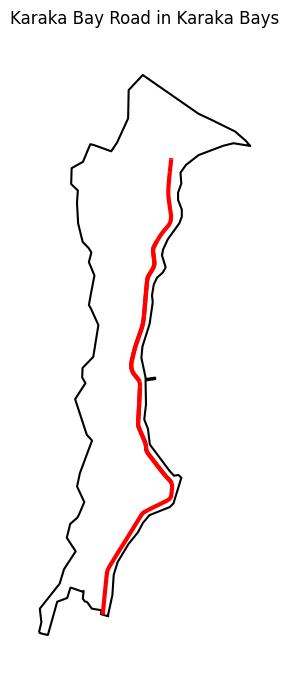

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))

chosen_area.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.5,
)

selected_route.plot(
    ax=ax,
    color="red",
    linewidth=3,
)

ax.set_title(f"{target_road_name} in {chosen_suburb}")
ax.set_axis_off()
ax.set_aspect("equal")

plt.show()

In [20]:
# Buffer distance used for the actual shade calculation
analysis_buffer_m = 7.5

# Slightly larger buffer used only to fetch nearby canopy polygons from the API
# This avoids missing polygons that touch the edge of the analysis corridor
fetch_buffer_m = 15

route_buffer = selected_route.geometry.buffer(fetch_buffer_m)
route_bbox = tuple(gpd.GeoSeries(route_buffer, crs="EPSG:2193").total_bounds)

route_canopy = load_canopy(route_bbox)

print(route_canopy.shape)
print(route_canopy.crs)

(451, 4)
EPSG:2193


In [21]:
karaka_bay_road_shade = route_shade(
    route_gdf=selected_route,
    canopy_gdf=route_canopy,
    buffer_m=analysis_buffer_m,
)

karaka_bay_road_shade[["road_name", "length_m", "shade_pct"]]

,road_name,length_m,shade_pct
8,Karaka Bay Road,543.423859,5.607793
20,Karaka Bay Road,366.162191,13.574279
21,Karaka Bay Road,366.162191,13.574279
34,Karaka Bay Road,17.780065,44.000431
52,Karaka Bay Road,3.583965,0.000000
70,Karaka Bay Road,506.922961,15.870971
71,Karaka Bay Road,506.922961,15.870971
84,Karaka Bay Road,249.368829,3.474072
93,Karaka Bay Road,43.700713,0.041555
95,Karaka Bay Road,4.084258,0.000000


In [22]:
karaka_bay_road_corridor = selected_route.geometry.buffer(analysis_buffer_m).union_all()

karaka_bay_road_canopy_clipped = gpd.clip(
    route_canopy,
    karaka_bay_road_corridor,
)

if karaka_bay_road_canopy_clipped.empty:
    canopy_area_m2 = 0
else:
    canopy_area_m2 = karaka_bay_road_canopy_clipped.geometry.union_all().area

corridor_area_m2 = karaka_bay_road_corridor.area
karaka_bay_road_overall_shade_pct = (canopy_area_m2 / corridor_area_m2) * 100

print(f"{target_road_name} walking corridor buffer: {analysis_buffer_m} m")
print(f"{target_road_name} corridor area: {corridor_area_m2:.2f} m²")
print(f"Canopy-covered area: {canopy_area_m2:.2f} m²")
print(f"Overall shade cover on {target_road_name}: {karaka_bay_road_overall_shade_pct:.2f}%")

Karaka Bay Road walking corridor buffer: 7.5 m
Karaka Bay Road corridor area: 26200.70 m²
Canopy-covered area: 2658.68 m²
Overall shade cover on Karaka Bay Road: 10.15%


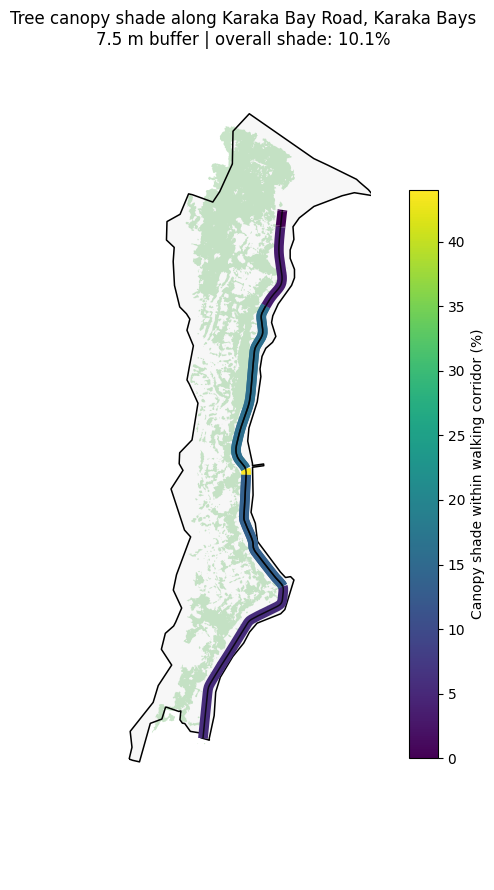

In [23]:
from shapely.geometry import box

analysis_buffer_m = 7.5

minx, miny, maxx, maxy = selected_route.total_bounds

# Zoomed out a little more
pad_x = 260
pad_y = 420

plot_box = box(minx - pad_x, miny - pad_y, maxx + pad_x, maxy + pad_y)
plot_box_gdf = gpd.GeoDataFrame(geometry=[plot_box], crs="EPSG:2193")

# Clip only the canopy and suburb fill to reduce clutter
local_canopy = gpd.clip(route_canopy, plot_box_gdf)
local_suburb_fill = gpd.clip(chosen_area, plot_box_gdf)

fig, ax = plt.subplots(figsize=(8, 9))
ax.set_facecolor("white")

# Light suburb fill
local_suburb_fill.plot(
    ax=ax,
    color="#f7f7f7",
    edgecolor="none",
)

# Canopy polygons
local_canopy.plot(
    ax=ax,
    color="#9bcf9b",
    alpha=0.55,
    edgecolor="none",
)

# Full suburb boundary, not clipped
chosen_area.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.1,
)

# Route coloured by shade percentage
karaka_bay_road_shade.plot(
    ax=ax,
    column="shade_pct",
    cmap="viridis",
    linewidth=7,
    legend=True,
    legend_kwds={
        "label": "Canopy shade within walking corridor (%)",
        "shrink": 0.7,
    },
)

# Thin road centreline on top
selected_route.plot(
    ax=ax,
    color="black",
    linewidth=1.1,
    alpha=0.8,
)

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

ax.set_title(
    f"Tree canopy shade along {target_road_name}, {chosen_suburb}\n"
    f"{analysis_buffer_m} m buffer | overall shade: "
    f"{karaka_bay_road_overall_shade_pct:.1f}%"
)

ax.set_axis_off()
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(
    "outputs/karaka_bay_road_shaded_map_final.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()